In [4]:
import pandas as pd

df = pd.read_csv("finalizedd.csv")

n = ["Age", "Blood_Pressure", "Cholesterol", "Glucose", "BMI"]
for i in n:
    df[i].fillna(df[i].median(), inplace=True)

b = ["Smoking", "Alcohol", "Physical_Activity", "Disease_Risk"]
for i in b:
    df[i].fillna(df[i].mode()[0], inplace=True)

df = df.drop_duplicates()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29396\219211952.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29396\219211952.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [5]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(df)

     Patient_ID   Age  Gender  Blood_Pressure  Cholesterol  Glucose    BMI  \
0             1  69.0  Female           100.0        162.0    151.0  33.50   
1             2  32.0  Female           166.0        290.0     92.0  31.90   
2             3  89.0    Male            92.0        167.0    152.0  19.10   
3             4  78.0    Male           132.0        245.0    178.0  37.90   
4             5  38.0    Male            95.0        272.0    144.0  38.00   
5             6  41.0  Female           139.0        221.0    198.0  35.20   
6             7  20.0  Female            99.0        195.0    157.0  18.20   
7             8  53.0    Male           132.0        178.0    123.0  19.30   
8             9  70.0    Male           112.0        211.0    158.0  23.00   
9            10  19.0  Female            99.0        165.0    134.0  20.90   
10           11  47.0  Female           133.0        270.0    145.0  28.45   
11           12  55.0    Male            91.0        159.0    12

In [6]:
for i in n:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[i] >= lower) & (df[i] <= upper)]

In [7]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(df)

     Patient_ID   Age  Gender  Blood_Pressure  Cholesterol  Glucose    BMI  \
0             1  69.0  Female           100.0        162.0    151.0  33.50   
1             2  32.0  Female           166.0        290.0     92.0  31.90   
2             3  89.0    Male            92.0        167.0    152.0  19.10   
3             4  78.0    Male           132.0        245.0    178.0  37.90   
4             5  38.0    Male            95.0        272.0    144.0  38.00   
5             6  41.0  Female           139.0        221.0    198.0  35.20   
6             7  20.0  Female            99.0        195.0    157.0  18.20   
7             8  53.0    Male           132.0        178.0    123.0  19.30   
8             9  70.0    Male           112.0        211.0    158.0  23.00   
9            10  19.0  Female            99.0        165.0    134.0  20.90   
10           11  47.0  Female           133.0        270.0    145.0  28.45   
11           12  55.0    Male            91.0        159.0    12

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[n] = scaler.fit_transform(df[n])

In [9]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(df)

     Patient_ID       Age  Gender  Blood_Pressure  Cholesterol   Glucose  \
0             1  0.798277  Female       -1.384596    -1.416984  0.441397   
1             2 -1.071342  Female        1.343427     1.638920 -1.169142   
2             3  1.808882    Male       -1.715265    -1.297613  0.468694   
3             4  1.253049    Male       -0.061918     0.564578  1.178423   
4             5 -0.768161    Male       -1.591264     1.209183  0.250316   
5             6 -0.616570  Female        0.227418    -0.008404  1.724368   
6             7 -1.677705  Female       -1.425929    -0.629134  0.605180   
7             8 -0.010207    Male       -0.061918    -1.034996 -0.322927   
8             9  0.848807    Male       -0.888591    -0.247146  0.632477   
9            10 -1.728235  Female       -1.425929    -1.345362 -0.022657   
10           11 -0.313389  Female       -0.020584     1.161435  0.277613   
11           12  0.090853    Male       -1.756599    -1.488607 -0.159143   
12          

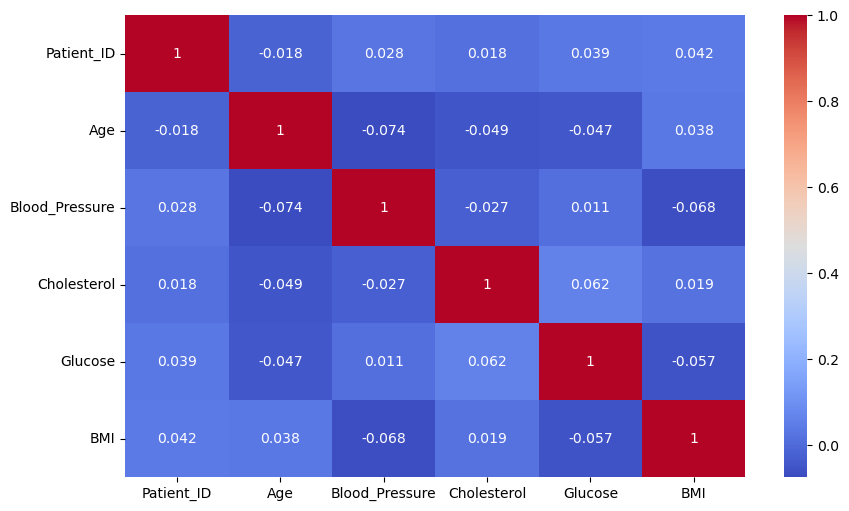

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop("Disease_Risk", axis=1)
y = df["Disease_Risk"]

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print(selected_features)

df = df[selected_features.tolist() + ["Disease_Risk"]]

Index(['Patient_ID', 'Gender', 'Cholesterol', 'BMI', 'Physical_Activity'], dtype='object')


In [15]:
print(df.dtypes)

Patient_ID             int64
Gender                 int64
Cholesterol          float64
BMI                  float64
Physical_Activity      int64
Disease_Risk           int64
dtype: object


In [16]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop(["Patient_ID", "Disease_Risk"], axis=1)
y = df["Disease_Risk"]

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print(selected_features)

df = df[selected_features.tolist() + ["Disease_Risk"]]

Index(['Gender', 'Cholesterol', 'BMI', 'Physical_Activity'], dtype='object')


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=5 is greater than n_features=4. All the features will be returned.
  warnings.warn(


In [17]:
print(X.head())

   Gender  Cholesterol       BMI  Physical_Activity
0       0    -1.416984  0.778441                  1
1       0     1.638920  0.514529                  1
2       1    -1.297613 -1.596766                  1
3       1     0.564578  1.504199                  1
4       1     1.209183  1.520694                  0


In [18]:
selector = SelectKBest(score_func=f_classif, k=4)

In [19]:
k = min(5, X.shape[1])

selector = SelectKBest(score_func=f_classif, k=k)

In [21]:
print(X.head())

   Gender  Cholesterol       BMI  Physical_Activity
0       0    -1.416984  0.778441                  1
1       0     1.638920  0.514529                  1
2       1    -1.297613 -1.596766                  1
3       1     0.564578  1.504199                  1
4       1     1.209183  1.520694                  0


In [22]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(df)

     Gender  Cholesterol       BMI  Physical_Activity  Disease_Risk
0         0    -1.416984  0.778441                  1             0
1         0     1.638920  0.514529                  1             0
2         1    -1.297613 -1.596766                  1             0
3         1     0.564578  1.504199                  1             2
4         1     1.209183  1.520694                  0             0
5         0    -0.008404  1.058848                  1             0
6         0    -0.629134 -1.745217                  1             2
7         1    -1.034996 -1.563777                  1             0
8         1    -0.247146 -0.953481                  0             0
9         0    -1.345362 -1.299865                  2             2
10        0     1.161435 -0.054531                  1             0
11        1    -1.488607  1.570177                  2             0
12        1     0.731698 -0.062778                  1             0
13        0     0.278087 -1.728722              

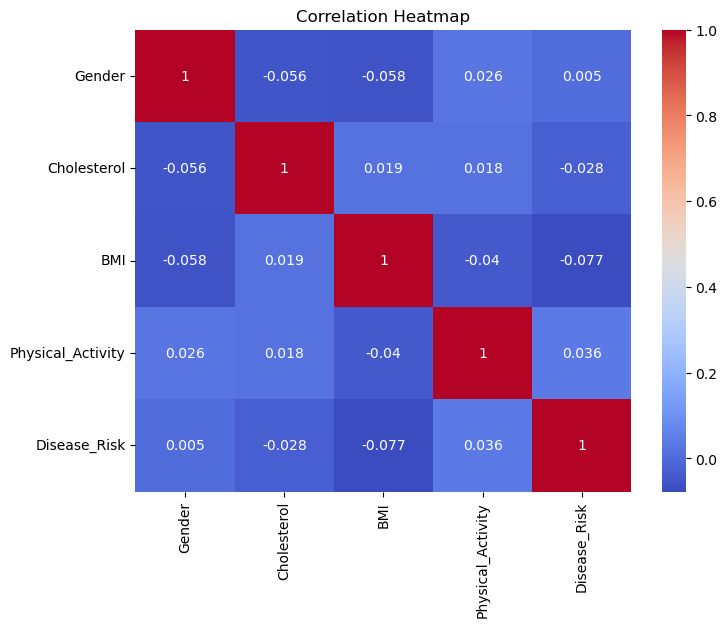

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

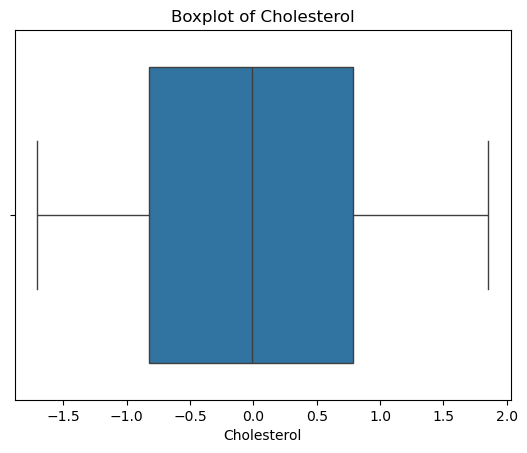

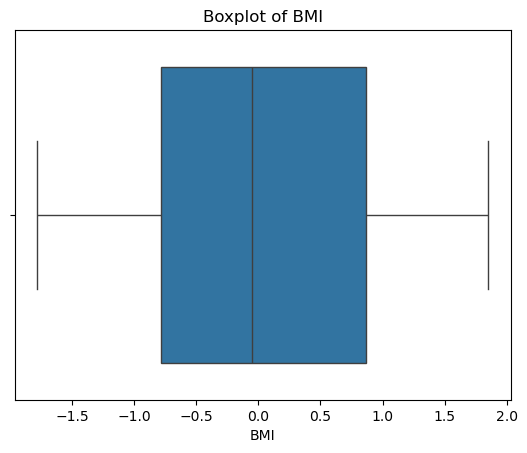

In [27]:
num_cols = ["Cholesterol", "BMI"]

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

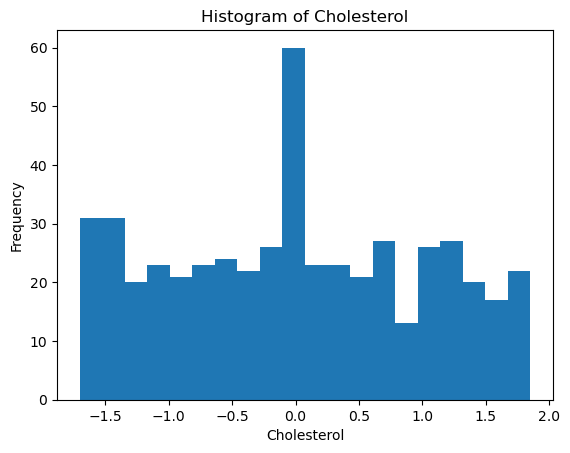

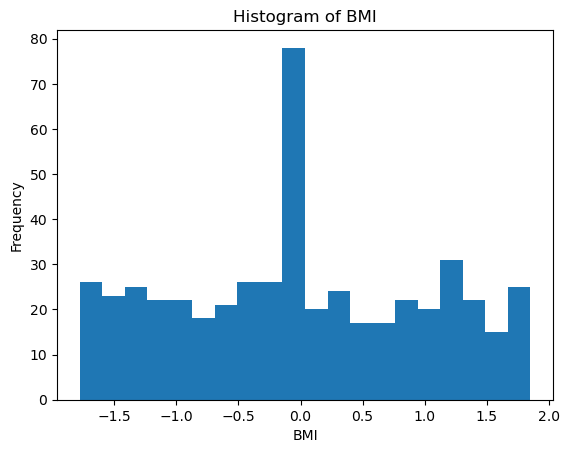

In [28]:
num_cols = ["Cholesterol", "BMI"]

for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

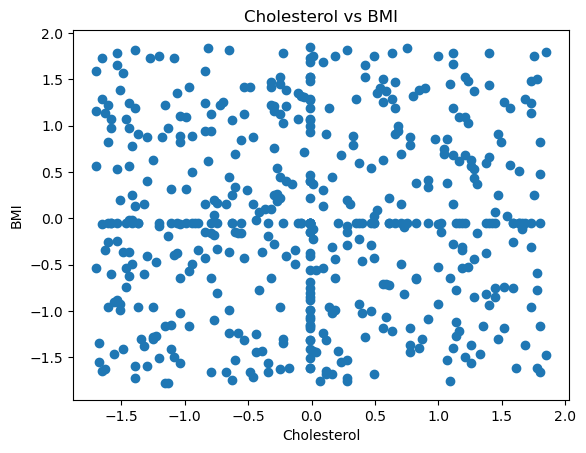

In [29]:
plt.figure()
plt.scatter(df["Cholesterol"], df["BMI"])
plt.title("Cholesterol vs BMI")
plt.xlabel("Cholesterol")
plt.ylabel("BMI")
plt.show()

In [30]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

X = df.drop("Disease_Risk", axis=1)
y = df["Disease_Risk"]

model = LogisticRegression()

# fwd
sfs_forward = SequentialFeatureSelector(model, n_features_to_select=2, direction='forward')
sfs_forward.fit(X, y)
fwd_features = X.columns[sfs_forward.get_support()]
print("fwd:", fwd_features)

# backwd
sfs_backward = SequentialFeatureSelector(model, n_features_to_select=2, direction='backward')
sfs_backward.fit(X, y)
backwd_features = X.columns[sfs_backward.get_support()]
print("backwd:", backwd_features)

fwd: Index(['Cholesterol', 'BMI'], dtype='object')
backwd: Index(['Cholesterol', 'BMI'], dtype='object')


In [31]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(df)

     Gender  Cholesterol       BMI  Physical_Activity  Disease_Risk
0         0    -1.416984  0.778441                  1             0
1         0     1.638920  0.514529                  1             0
2         1    -1.297613 -1.596766                  1             0
3         1     0.564578  1.504199                  1             2
4         1     1.209183  1.520694                  0             0
5         0    -0.008404  1.058848                  1             0
6         0    -0.629134 -1.745217                  1             2
7         1    -1.034996 -1.563777                  1             0
8         1    -0.247146 -0.953481                  0             0
9         0    -1.345362 -1.299865                  2             2
10        0     1.161435 -0.054531                  1             0
11        1    -1.488607  1.570177                  2             0
12        1     0.731698 -0.062778                  1             0
13        0     0.278087 -1.728722              

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[["Cholesterol", "BMI"]] = scaler.fit_transform(df[["Cholesterol", "BMI"]])

In [33]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(df)

     Gender  Cholesterol       BMI  Physical_Activity  Disease_Risk
0         0     0.080537  0.704545                  1             0
1         0     0.939597  0.631818                  1             0
2         1     0.114094  0.050000                  1             0
3         1     0.637584  0.904545                  1             2
4         1     0.818792  0.909091                  0             0
5         0     0.476510  0.781818                  1             0
6         0     0.302013  0.009091                  1             2
7         1     0.187919  0.059091                  1             0
8         1     0.409396  0.227273                  0             0
9         0     0.100671  0.131818                  2             2
10        0     0.805369  0.475000                  1             0
11        1     0.060403  0.922727                  2             0
12        1     0.684564  0.472727                  1             0
13        0     0.557047  0.013636              